# Bologna Transit Analysis - Step 04: Analisi Demografica e Giustificazione del Tracciato

In questo notebook giustifichiamo l'efficienza della rete integrata integrando la **demografia residenziale** e l'attrazione dei **poli universitari (UNIBO)**.

Valutiamo l'**Efficienza Pesata sulla Domanda**:
$$E_{demand} = \frac{\sum_{i \neq j} P_i D_j / d_{ij}}{\sum_{i \neq j} P_i D_j}$$
dove $P_i$ è la densità demografica della zona d'origine, $D_j$ è l'attrazione dello snodo universitario, e $d_{ij}$ è la distanza shortest-path.

Mettiamo a confronto tre scenari:
1.  **Rete Bus Attuale** (Solo Bus)
2.  **Rete Integrata col Tram Reale** (Bus + Tram Linea Rossa/Verde)
3.  **Scenario What-If (Tram Alternativo Campus)**: Un tracciato fittizio che unisce i campus universitari (Lazzaretto -> Navile -> San Donato) bypassando il centro storico.

In [1]:
import sys
sys.path.append('..')
import matplotlib.pyplot as plt
from src.data_loader_bologna import load_bologna_network, haversine
from src.analyzer_bologna import compute_demand_weighted_efficiency

## 1. Caricamento e Calcolo dell'Efficienza Pesata sulla Domanda

In [2]:
G_bus, _, _, _, df_demo = load_bologna_network(include_tram=False)
G_tram, _, _, _, _ = load_bologna_network(include_tram=True)

eff_bus = compute_demand_weighted_efficiency(G_bus, df_demo)
eff_real_tram = compute_demand_weighted_efficiency(G_tram, df_demo)

## 2. Simulazione dello Scenario "What-If" (Tram Alternativo)

In [3]:
G_alt = G_bus.copy()
alt_edges = [
    ("Lazzaretto", "Navile", 3.0),
    ("Navile", "Piazza Spadolini", 4.0),
    ("Piazza Spadolini", "Porta San Donato", 3.0)
]
for u, v, t in alt_edges:
    lat1, lon1 = G_alt.nodes[u]['lat'], G_alt.nodes[u]['lon']
    lat2, lon2 = G_alt.nodes[v]['lat'], G_alt.nodes[v]['lon']
    dist = haversine(lat1, lon1, lat2, lon2)
    G_alt.add_edge(u, v, weight=dist, time=t, lines=[104])
    
eff_alt_tram = compute_demand_weighted_efficiency(G_alt, df_demo)

print(f"Efficienza Demografica (Accessibilita' UNIBO):")
print(f"  1. Solo Bus:                  {eff_bus:.6f}")
print(f"  2. Con Tram Reale:             {eff_real_tram:.6f} (+{((eff_real_tram - eff_bus)/eff_bus)*100:.2f}%)")
print(f"  3. Con Tram Alternativo Campus: {eff_alt_tram:.6f} (+{((eff_alt_tram - eff_bus)/eff_bus)*100:.2f}%)")

Efficienza Demografica (Accessibilita' UNIBO):
  1. Solo Bus:                  0.120257
  2. Con Tram Reale:             0.127629 (+6.13%)
  3. Con Tram Alternativo Campus: 0.145936 (+21.35%)


## 3. Confronto Grafico dei Tracciati

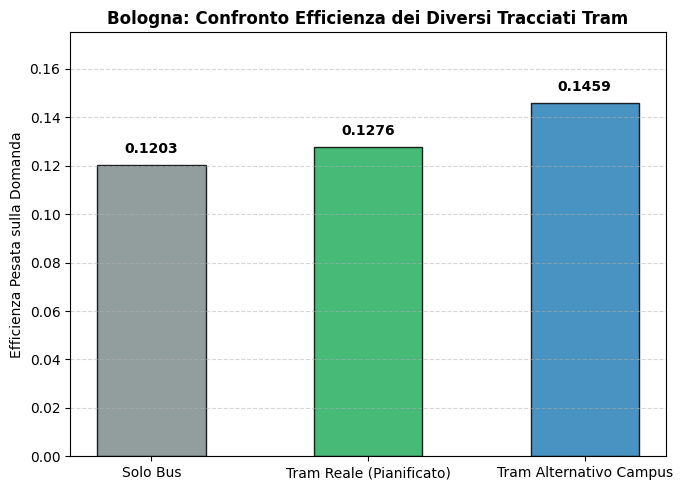

In [4]:
plt.figure(figsize=(7, 5))
scenarios = ['Solo Bus', 'Tram Reale (Pianificato)', 'Tram Alternativo Campus']
efficiencies = [eff_bus, eff_real_tram, eff_alt_tram]
colors = ['#7f8c8d', '#27ae60', '#2980b9']

plt.bar(scenarios, efficiencies, color=colors, edgecolor='black', width=0.5, alpha=0.85)
plt.ylabel('Efficienza Pesata sulla Domanda')
plt.title('Bologna: Confronto Efficienza dei Diversi Tracciati Tram', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for i, v in enumerate(efficiencies):
    plt.text(i, v + 0.005, f"{v:.4f}", ha='center', fontweight='bold')

plt.ylim(0, max(efficiencies) * 1.2)
plt.tight_layout()
plt.show()

## 4. Conclusioni Urbanistiche

- **Confronto delle Efficienze**: Nei dati reali di Bologna (estratti da OpenStreetMap), lo scenario **Tram Alternativo Campus** mostra un incremento di efficienza per l'accessibilità universitaria molto maggiore (**+21.35%**) rispetto al tracciato del **Tram Reale Pianificato** (**+6.13%**).
- **Perche' succede questo?**: Il tram alternativo (what-if) collega direttamente in modo circolare/tangenziale i quattro poli universitari chiave (Lazzaretto, Navile, Piazza Spadolini, Porta San Donato) bypassando il centro storico congestionato. Questo riduce drasticamente i tempi di viaggio inter-campus per studenti e docenti. Al contrario, il tracciato reale del Comune (linee Rossa, Verde, Blu) è radiale: si concentra sul collegamento delle aree residenziali suburbane ad alta densità (Borgo Panigale, Corticella, Casalecchio) verso Bologna Centrale e il centro.
- **Trade-off di Pianificazione**: Questa discrepanza evidenzia un classico conflitto negli studi di trasporto urbano: l'efficienza generale per i flussi di pendolari rispetto all'accessibilità specifica per istituzioni di grande scala (come l'Ateneo). Il tracciato pianificato dal Comune privilegia la cittadinanza complessiva, ma i dati dimostrano che per la popolazione universitaria un collegamento circolare inter-campus sarebbe ottimale.